# Formation DSA : Introduction à la causalité pour l'actuaire

Auteur Fabien FAIVRE : ffaivre@macif.fr

L'objet de ce classeur est de proposer un premier contact avec l'inférence causale à destination des actuaires.

## Mise en place de l'environnement de travail

================== DEBUT du SETUP d'environnement =======================

In [1]:
!python -V

Python 3.13.15


In [2]:
# Colab (Python 3.13) fournit déjà numpy 2.x : on NE force PAS de version de numpy.
# Les versions récentes des packages causaux ci-dessous sont toutes compatibles numpy 2.
import numpy, pandas, sklearn
print('numpy', numpy.__version__, '| pandas', pandas.__version__, '| scikit-learn', sklearn.__version__)

numpy 2.1.3 | pandas 2.2.3 | scikit-learn 1.6.1


**NB** : il n'est plus nécessaire de forcer `numpy==1.26.4` ni de redémarrer la session avant l'installation : les versions récentes de DoWhy, EconML, CausalML et DoubleML fonctionnent avec numpy 2 et Python 3.13.

DoWhy 0.14 est compatible avec la version de `networkx` fournie par Colab : il n'est plus nécessaire d'en forcer l'installation.

In [3]:
import networkx
print('networkx', networkx.__version__)

networkx 3.6.1


In [4]:
!pip install -q doubleml==0.11.4 econml==0.17.0 causalml==0.17.0 dowhy==0.14 tableone==0.9.6 catboost==1.2.10

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.7/44.7 kB 1.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 42.1 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.1/95.1 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 607.8/607.8 kB 36.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 77.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 403.1/403.1 kB 25.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.9/76.9 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 64.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 245.9/245.9 kB 17.9 MB/s eta 0:0

Pour permettre un affichage agréable des graph causaux il est nécessaire d'installer pygraphviz. Depuis la version 2.0, pygraphviz est distribué sous forme de wheel précompilée : l'installation de `libgraphviz-dev` reste proposée par sécurité.

In [5]:
# Pour le bon affichage des modules de visualisation
!apt-get install -y -qq libgraphviz-dev > /dev/null
!pip install -q pygraphviz==2.0.3

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 67.0 MB/s eta 0:00:00


================== FIN du SETUP d'environnement =======================

## Définition du cas d'usage

Afin de fixer les idées, nous allons nous intéresser à un cas inspiré du marketing.

--- Vérification du calibrage (sur les données complètes) ---
Objectif E[Y(0)] : 75.00%
Réel     E[Y(0)] : 71.59%

Objectif E[Y(1)] : 80.00%
Réel     E[Y(1)] : 76.15%

Objectif ATE    : 5.00%
Réel     ATE    : 4.55%


Distribution des segments pour les données calibrées :
segment
Acquis             54.150
Persuadable        21.996
Ne pas déranger    17.444
Cause perdue        6.410
Name: proportion, dtype: float64


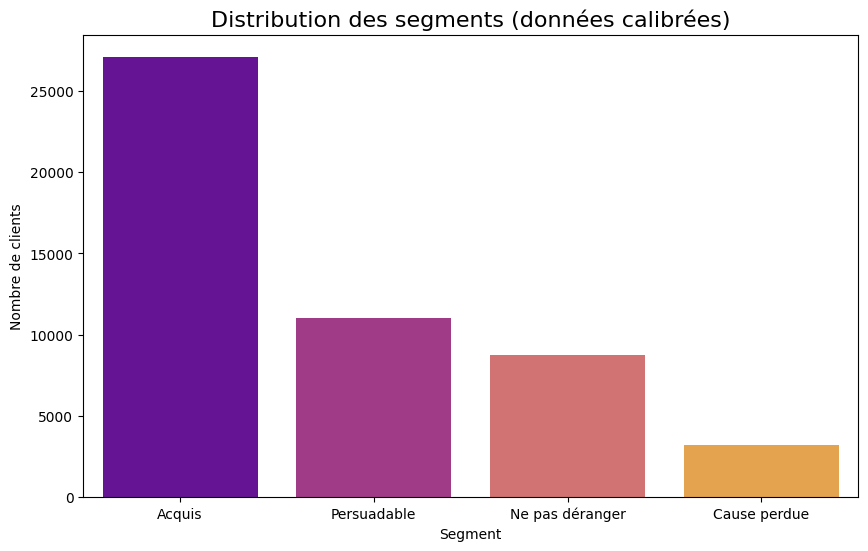

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Graine aléatoire : rend les résultats reproductibles d'une exécution à l'autre
np.random.seed(2)

def generate_final_calibrated_data(
    n_samples: int = 50000,
    n_features: int = 12,
    target_y0_mean: float = 0.75,
    target_ate: float = 0.05
) -> (pd.DataFrame, pd.DataFrame):
    """
    Génère un jeu de données synthétique avec un E[Y0] et un ATE cibles, de manière robuste.
    Inclut les segments, le collider et retourne les DataFrames biaisé et non biaisé.

    Paramètres :
        n_samples (int) : nombre d'échantillons à générer.
        n_features (int) : nombre de variables explicatives.
        target_y0_mean (float) : taux de conversion moyen désiré sans traitement.
        target_ate (float) : effet moyen du traitement désiré.

    Retour :
        tuple[pd.DataFrame, pd.DataFrame] :
            - le DataFrame complet et non biaisé ;
            - le DataFrame biaisé après sélection par le collider.
    """
    # --- Étape 1 : calcul des paramètres de calibrage ---
    target_y1_mean = target_y0_mean + target_ate
    def logit(p):
        epsilon = 1e-10
        p = np.clip(p, epsilon, 1 - epsilon)
        return np.log(p / (1 - p))

    intercept_y0 = logit(target_y0_mean)
    intercept_y1 = logit(target_y1_mean)

    # --- Étape 2 : génération des variables explicatives et du traitement ---
    X = pd.DataFrame(np.random.normal(0, 1, size=(n_samples, n_features)),
                       columns=[f'feature_{i+1}' for i in range(n_features)])

    propensity_coeffs = np.random.uniform(-0.5, 0.5, n_features)
    propensity_logit = np.dot(X, propensity_coeffs)
    sigmoid = lambda x: 1 / (1 + np.exp(-x))
    propensity_prob = sigmoid(propensity_logit)
    treatment = np.random.binomial(1, propensity_prob)

    # --- Étape 3 : génération des probabilités de l'outcome ---
    # Coefficients distincts pour Y0 et Y1 : l'effet du traitement varie selon les individus
    outcome_coeffs_y0 = np.random.uniform(-0.5, 0.5, n_features)
    outcome_coeffs_y1 = np.random.uniform(-0.5, 0.5, n_features)

    # Logit de Y(0), centré sur la constante intercept_y0
    logit_y0 = np.dot(X, outcome_coeffs_y0) + intercept_y0
    p_outcome_untreated = sigmoid(logit_y0)

    # Logit de Y(1), centré sur la constante intercept_y1
    logit_y1 = np.dot(X, outcome_coeffs_y1) + intercept_y1
    p_outcome_treated = sigmoid(logit_y1)

    # --- Étape 4 : tirage des outcomes potentiels et de l'outcome observé ---
    Y0 = np.random.binomial(1, p_outcome_untreated)
    Y1 = np.random.binomial(1, p_outcome_treated)
    observed_outcome = treatment * Y1 + (1 - treatment) * Y0

    # --- Étape 5 : assemblage du DataFrame complet ---
    full_unbiased_df = X.copy()
    full_unbiased_df['treatment'] = treatment
    full_unbiased_df['Y0'] = Y0
    full_unbiased_df['Y1'] = Y1
    full_unbiased_df['outcome'] = observed_outcome
    full_unbiased_df['ite_prob'] = p_outcome_treated - p_outcome_untreated

    conditions = [
        (full_unbiased_df['Y0'] == 0) & (full_unbiased_df['Y1'] == 1),
        (full_unbiased_df['Y0'] == 1) & (full_unbiased_df['Y1'] == 1),
        (full_unbiased_df['Y0'] == 1) & (full_unbiased_df['Y1'] == 0),
        (full_unbiased_df['Y0'] == 0) & (full_unbiased_df['Y1'] == 0)
    ]
    # Segments d'uplift : Persuadable (Y0=0, Y1=1), Acquis (Y0=1, Y1=1),
    # Ne pas déranger (Y0=1, Y1=0), Cause perdue (Y0=0, Y1=0)
    choices = ['Persuadable', 'Acquis', 'Ne pas déranger', 'Cause perdue']
    full_unbiased_df['segment'] = np.select(conditions, choices, default='Erreur')

    # --- Étape 6 : ajout du collider ---
    collider_logit = 1.2 * full_unbiased_df['treatment'] + 1.5 * full_unbiased_df['outcome'] - 1.0
    prob_selection = sigmoid(collider_logit)
    selection = np.random.binomial(1, prob_selection)
    full_unbiased_df['selection_collider'] = selection

    # --- Étape 7 : création du jeu de données biaisé ---
    biased_df = full_unbiased_df[full_unbiased_df['selection_collider'] == 1].copy()

    return full_unbiased_df, biased_df

# --- Génération des données et vérification ---
TARGET_Y0_MEAN = 0.75
TARGET_ATE = 0.05

full_df, biased_df = generate_final_calibrated_data(
    target_y0_mean=TARGET_Y0_MEAN,
    target_ate=TARGET_ATE
)

# --- Vérification du calibrage sur la POPULATION TOTALE ---
print("--- Vérification du calibrage (sur les données complètes) ---")
actual_y0_mean = full_df['Y0'].mean()
actual_y1_mean = full_df['Y1'].mean()
actual_ate = actual_y1_mean - actual_y0_mean

print(f"Objectif E[Y(0)] : {TARGET_Y0_MEAN:.2%}")
print(f"Réel     E[Y(0)] : {actual_y0_mean:.2%}\n")

print(f"Objectif E[Y(1)] : {TARGET_Y0_MEAN + TARGET_ATE:.2%}")
print(f"Réel     E[Y(1)] : {actual_y1_mean:.2%}\n")

print(f"Objectif ATE    : {TARGET_ATE:.2%}")
print(f"Réel     ATE    : {actual_ate:.2%}\n")

# Affichage de la distribution des segments
print("\nDistribution des segments pour les données calibrées :")
segment_counts = full_df['segment'].value_counts(normalize=True) * 100
print(segment_counts)

# Visualisation de la distribution
plt.figure(figsize=(10, 6))
sns.countplot(x='segment', hue='segment', data=full_df, order=segment_counts.index, palette='plasma', legend=False)
plt.title('Distribution des segments (données calibrées)', fontsize=16)
plt.ylabel('Nombre de clients')
plt.xlabel('Segment')
plt.show()

In [7]:
full_df

,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,feature_10,feature_11,feature_12,treatment,Y0,Y1,outcome,ite_prob,segment,selection_collider
0,-0.416758,-0.056267,-2.136196,1.640271,-1.793436,-0.841747,0.502881,-1.245288,-1.057952,-0.909008,0.551454,2.292208,0,1,1,1,-0.326153,Acquis,0
1,0.041539,-1.117925,0.539058,-0.596160,-0.019130,1.175001,-0.747871,0.009025,-0.878108,-0.156434,0.256570,-0.988779,1,0,1,1,0.141264,Persuadable,1
2,-0.338822,-0.236184,-0.637655,-1.187612,-1.421217,-0.153495,-0.269057,2.231367,-2.434768,0.112727,0.370445,1.359634,1,0,1,1,0.241479,Persuadable,1
3,0.501857,-0.844214,0.000010,0.542353,-0.313508,0.771012,-1.868091,1.731185,1.467678,-0.335677,0.611341,0.047971,1,1,1,1,0.104105,Acquis,1
4,-0.829135,0.087710,1.000366,-0.381093,-0.375669,-0.074471,0.433496,1.278379,-0.634679,0.508396,0.216116,-1.858612,1,1,1,1,0.361980,Acquis,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,-1.798899,1.064090,-0.471910,-1.373077,0.197200,-0.803728,-0.282817,-0.850382,-1.652535,0.284520,1.723747,-0.548389,0,1,1,1,0.098201,Acquis,0
49996,0.531494,0.298989,0.314075,-0.701788,-0.042904,1.668744,-1.474496,-0.953418,-0.219675,-0.002317,-0.425727,0.234401,0,1,1,1,-0.358199,Acquis,1
49997,1.492215,-0.376034,-0.167829,0.632488,0.861685,-1.906029,1.669231,1.434443,-1.961631,0.798140,-1.059189,0.438425,0,0,1,0,0.563733,Persuadable,1
49998,0.032493,0.253140,-0.662908,-0.727474,-1.382108,0.528057,0.676494,1.851946,-1.796946,0.291739,0.100221,0.563554,1,1,1,1,0.197452,Acquis,1


**Question** : Pourquoi souhaite-t-on travailler avec un jeu de données simulées ?

In [8]:
 url_raw = 'https://raw.githubusercontent.com/Fabien-DS/DSA_Causal/main/full_df.parquet'

# Lecture du fichier Parquet directement depuis l'URL
try:
    df = pd.read_parquet(url_raw)
    print("Fichier Parquet lu avec succès !")
    print(df.head())
except Exception as e:
    print(f"Une erreur est survenue : {e}")
    print("Vérifiez que votre URL est bien une URL 'raw' et que le dépôt est public.")

Fichier Parquet lu avec succès !
   feature_1  feature_2  feature_3  feature_4  feature_5  feature_6  \
0   1.020003  -1.085647   1.252751   1.492513   1.295669  -0.146288   
1   0.171507   0.860206   1.389396  -2.171336   0.407673   0.566109   
2   0.020553   0.683664  -0.142949   0.651932   1.031460   0.785116   
3   0.441661   0.113539  -1.183310   1.869493  -1.571153   1.443348   
4  -0.375112  -0.366178  -1.092826   0.466952  -0.562258   2.208661   

   feature_7  feature_8  feature_9  feature_10  feature_11  feature_12  \
0  -0.106084  -1.857188  -1.303645   -1.217982    2.222917    1.553337   
1  -1.220901   0.274051  -0.441126    0.016279   -1.749869    1.611843   
2   0.375169   0.111109   1.639418    0.924066   -0.631359   -2.095132   
3   0.411133   1.270447  -0.049342    0.444233   -0.868300   -0.071359   
4  -1.100441   0.170663   0.481724    0.355912   -1.117091   -0.093695   

   treatment  Y0  Y1  outcome  ite_prob       segment  selection_collider  
0          1   1   

## Les 4 étapes du processus Causal

La Causalité suit un [processus en 4 étapes](https://www.pywhy.org/dowhy/v0.10.1/user_guide/causal_tasks/estimating_causal_effects/index.html) tel que matérialisé dans le package [DoWhy](https://www.pywhy.org/dowhy/v0.12/)

![dowhy-schematic](https://raw.githubusercontent.com/microsoft/dowhy/main/docs/images/dowhy-schematic.png)



## Étape 1 : réfléchir au problème => définition du graphe causal

(Optionnel) : avant même d'avoir des données !

Il est possible de commencer à poser ses hypothèses sur un projet avant même de collecter des données. Loin d'être anecdotique, cette étape permet d'expliciter des hypothèses qui sans cela resteraient implicites. Cette étape est particulièrement adaptée pour échanger avec des experts métier, qui détiennent une expertise du domaine. En explicitant les hypothèses sur les processus à l'origine des données, il est possible de générer des discussions fructueuses.

![DAG](https://github.com/Fabien-DS/DSA_Causal/blob/main/images/CausalDAG.png?raw=true)

À titre d'exemple, après une série d'entretiens de découverte avec des experts métier, vous avez déterminé :

- que vous souhaitez connaître l'impact de la variable `treatment` (ex : un appel téléphonique) sur la variable `outcome` (le maintien en portefeuille) ;

- que plusieurs variables confondantes (c.-à-d. des ancêtres communs de `treatment` et `outcome`) existent, appelées `feature_1` à `feature_12` ;

- enfin, qu'une variable `selection_collider` est un collider (c.-à-d. un descendant de `treatment` et de `outcome`).

In [9]:
import numpy as np
import pandas as pd
import scipy.stats as stats

import doubleml as dml

from dowhy import CausalModel

from sklearn.model_selection import train_test_split

import seaborn as sns
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')

import graphviz

On commence par nommer les variables qui nous intéressent :

In [10]:
columns=['outcome', 'treatment'] + [f"feature_{k}" for k in range(1,13)] + ['selection_collider']
columns

['outcome',
 'treatment',
 'feature_1',
 'feature_2',
 'feature_3',
 'feature_4',
 'feature_5',
 'feature_6',
 'feature_7',
 'feature_8',
 'feature_9',
 'feature_10',
 'feature_11',
 'feature_12',
 'selection_collider']

Puis on peut renseigner les liens entre ces variables.

In [11]:
causal_graph = """
digraph {
feature_1 -> outcome;
feature_2 -> outcome;
feature_3 -> outcome;
feature_4 -> outcome;
feature_5 -> outcome;
feature_6 -> outcome;
feature_7 -> outcome;
feature_8 -> outcome;
feature_9 -> outcome;
feature_10 -> outcome;
feature_11 -> outcome;
feature_12 -> outcome;
feature_1 -> treatment;
feature_2 -> treatment;
feature_3 -> treatment;
feature_4 -> treatment;
feature_5 -> treatment;
feature_6 -> treatment;
feature_7 -> treatment;
feature_8 -> treatment;
feature_9 -> treatment;
feature_10 -> treatment;
feature_11 -> treatment;
feature_12 -> treatment;
treatment -> outcome;
treatment -> selection_collider;
outcome -> selection_collider;
}
"""

L'astuce consiste à créer un DataFrame pandas vide avec le nom des variables que nous avons choisi de modéliser.

In [12]:
df_model = pd.DataFrame(columns=columns)
df_model

,outcome,treatment,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,feature_10,feature_11,feature_12,selection_collider


Il devient alors possible de tirer parti de la puissance de DoWhy en initialisant un objet de classe [CausalModel](https://www.pywhy.org/dowhy/v0.12/dowhy.html#module-dowhy.causal_model)

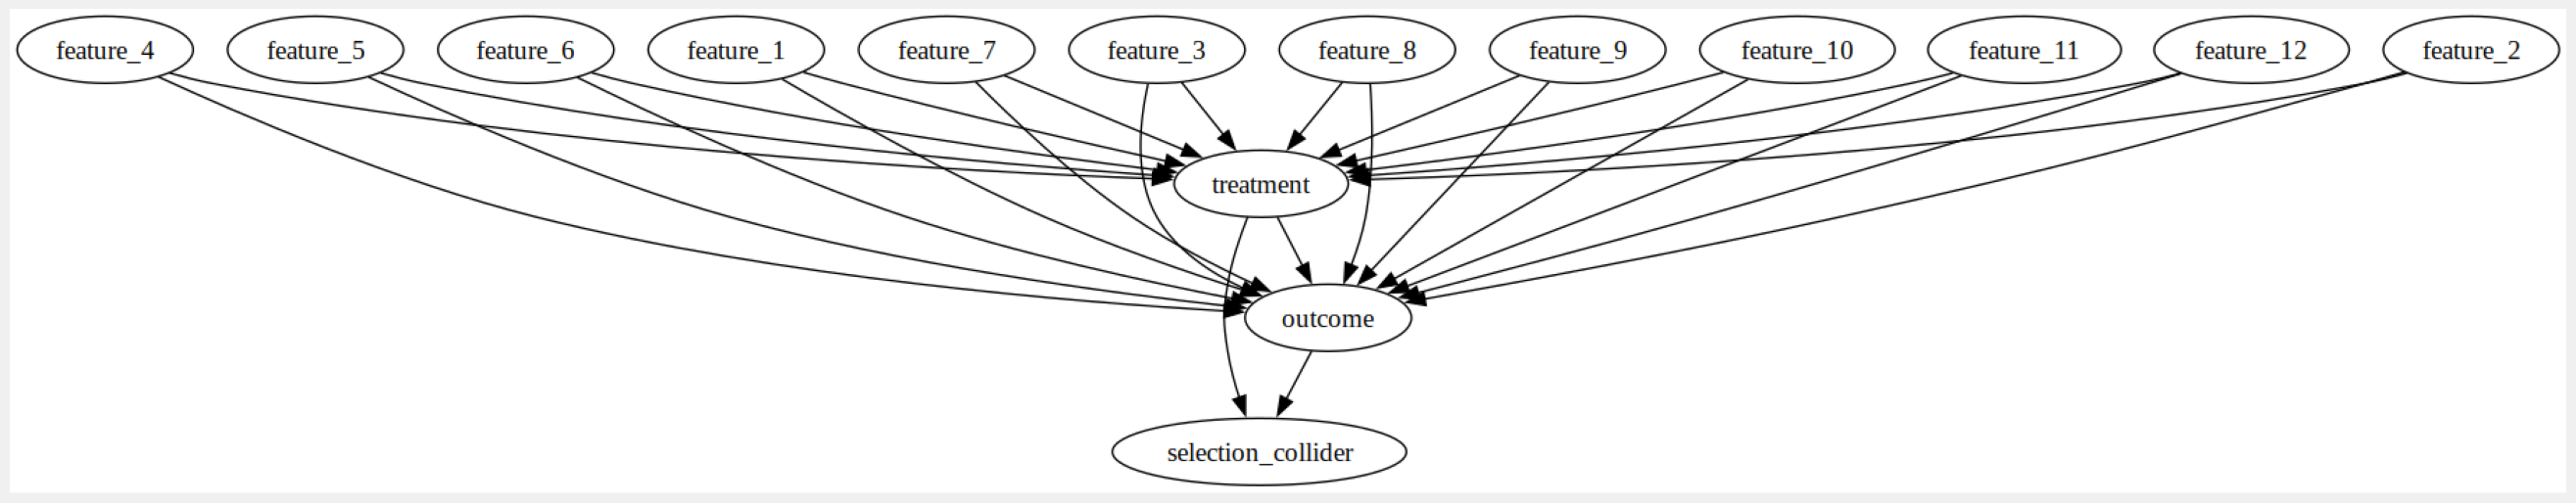

In [13]:
model= CausalModel(
          data=df_model, # Données
          graph=causal_graph, # DAG
          treatment='treatment', # Traitement
          outcome='outcome' # Variable d'intérêt
        )

# Affichage du graphe causal
model.view_model(size=(30,30))

DoWhy propose une mise en forme par défaut, mais celle-ci dépend du module pygraphviz et il n'est pas possible d'en changer manuellement l'agencement.
Une autre option consiste alors à utiliser l'application web DAGitty.

### (Optionnel) Étape 1 bis : DAGitty

DAGitty est une application web pour créer, éditer et analyser des diagrammes causaux.
Pour pouvoir réutiliser le graphe que nous avons défini à l'étape précédente, il nous faut modifier légèrement le format du DAG :

In [14]:
causal_graph_daggity = (
    causal_graph
    .replace('digraph {\n', 'dag {\n"')
    .replace("; ", '"\n"')
    .replace(";", '"\n"')
    .replace('"\n"\n', '"\n"')
    .replace(' -> ', '" -> "')
    .replace('"}', '}')
)
print(causal_graph_daggity)


dag {
"feature_1" -> "outcome"
"feature_2" -> "outcome"
"feature_3" -> "outcome"
"feature_4" -> "outcome"
"feature_5" -> "outcome"
"feature_6" -> "outcome"
"feature_7" -> "outcome"
"feature_8" -> "outcome"
"feature_9" -> "outcome"
"feature_10" -> "outcome"
"feature_11" -> "outcome"
"feature_12" -> "outcome"
"feature_1" -> "treatment"
"feature_2" -> "treatment"
"feature_3" -> "treatment"
"feature_4" -> "treatment"
"feature_5" -> "treatment"
"feature_6" -> "treatment"
"feature_7" -> "treatment"
"feature_8" -> "treatment"
"feature_9" -> "treatment"
"feature_10" -> "treatment"
"feature_11" -> "treatment"
"feature_12" -> "treatment"
"treatment" -> "outcome"
"treatment" -> "selection_collider"
"outcome" -> "selection_collider"
}



Le DAG ci-dessus est à coller dans [DAGitty](https://www.dagitty.net/dags.html), dans le panneau de droite, section « Model Code », puis cliquez sur « Update DAG » :
- sélectionnez le nœud `outcome` et attribuez-lui le statut « Outcome » (panneau en haut à gauche) ;
- sélectionnez le nœud `treatment` et attribuez-lui le statut « Exposure » (panneau en haut à gauche).

Quelles sont les implications testables de ce modèle ?

+

+

+

+

...

Il est possible de modifier la disposition du graphe à la main pour en faciliter la lecture. Voici un exemple de disposition (récupéré en copiant le code du DAG après avoir déplacé les nœuds) :

In [15]:
"""
dag {
bb="-3.99,-3.968,3.904,3.978"
feature_1 [pos="-2.429,-2.907"]
feature_10 [pos="1.696,-2.880"]
feature_11 [pos="2.254,-2.854"]
feature_12 [pos="2.912,-2.775"]
feature_2 [pos="-2.067,-2.907"]
feature_3 [pos="-1.598,-2.863"]
feature_4 [pos="-1.242,-2.898"]
feature_5 [pos="-0.790,-2.907"]
feature_6 [pos="-0.333,-2.907"]
feature_7 [pos="0.135,-2.863"]
feature_8 [pos="0.632,-2.872"]
feature_9 [pos="1.139,-2.880"]
outcome [outcome,pos="0.626,0.189"]
selection_collider [pos="0.029,1.522"]
treatment [exposure,pos="-0.539,0.198"]
feature_1 -> outcome
feature_1 -> treatment
feature_10 -> outcome
feature_10 -> treatment
feature_11 -> outcome
feature_11 -> treatment
feature_12 -> outcome
feature_12 -> treatment
feature_2 -> outcome
feature_2 -> treatment
feature_3 -> outcome
feature_3 -> treatment
feature_4 -> outcome
feature_4 -> treatment
feature_5 -> outcome
feature_5 -> treatment
feature_6 -> outcome
feature_6 -> treatment
feature_7 -> outcome
feature_7 -> treatment
feature_8 -> outcome
feature_8 -> treatment
feature_9 -> outcome
feature_9 -> treatment
outcome -> selection_collider
treatment -> outcome
treatment -> selection_collider
}

"""

'\ndag {\nbb="-3.99,-3.968,3.904,3.978"\nfeature_1 [pos="-2.429,-2.907"]\nfeature_10 [pos="1.696,-2.880"]\nfeature_11 [pos="2.254,-2.854"]\nfeature_12 [pos="2.912,-2.775"]\nfeature_2 [pos="-2.067,-2.907"]\nfeature_3 [pos="-1.598,-2.863"]\nfeature_4 [pos="-1.242,-2.898"]\nfeature_5 [pos="-0.790,-2.907"]\nfeature_6 [pos="-0.333,-2.907"]\nfeature_7 [pos="0.135,-2.863"]\nfeature_8 [pos="0.632,-2.872"]\nfeature_9 [pos="1.139,-2.880"]\noutcome [outcome,pos="0.626,0.189"]\nselection_collider [pos="0.029,1.522"]\ntreatment [exposure,pos="-0.539,0.198"]\nfeature_1 -> outcome\nfeature_1 -> treatment\nfeature_10 -> outcome\nfeature_10 -> treatment\nfeature_11 -> outcome\nfeature_11 -> treatment\nfeature_12 -> outcome\nfeature_12 -> treatment\nfeature_2 -> outcome\nfeature_2 -> treatment\nfeature_3 -> outcome\nfeature_3 -> treatment\nfeature_4 -> outcome\nfeature_4 -> treatment\nfeature_5 -> outcome\nfeature_5 -> treatment\nfeature_6 -> outcome\nfeature_6 -> treatment\nfeature_7 -> outcome\nfeatur

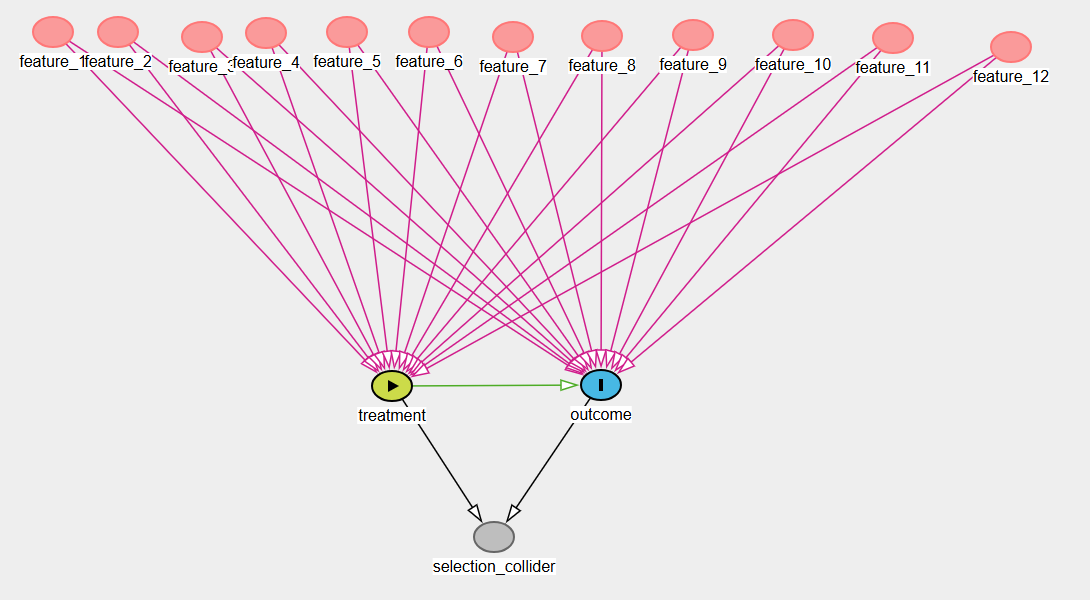

## Étape 2 : l'effet du traitement sur l'outcome est-il identifiable ?

Nous nous intéressons à l'effet du traitement (`treatment`) sur la variable d'intérêt (`outcome`) dans la population générale.
D'un point de vue causal, cette quantité s'écrit :

$$ ATE = E\left[ outcome \mid do(treatment=1)\right] - E\left[ outcome \mid do(treatment=0)\right]$$

Cette quantité n'est pas directement observable. La question est de savoir s'il existe une *« recette »* qui permette de se ramener à des quantités observables (c.-à-d. des probabilités conditionnelles).

DoWhy permet de mener cette étape pour nous.

In [16]:
identified_estimand = model.identify_effect(proceed_when_unidentifiable=True)

print(identified_estimand)

Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
     d                                                                         ↪
────────────(E[outcome|feature_11,feature_12,feature_5,feature_7,feature_1,fea ↪
d[treatment]                                                                   ↪

↪                                                                      
↪ ture_9,feature_2,feature_8,feature_6,feature_10,feature_3,feature_4])
↪                                                                      
Estimand assumption 1, Unconfoundedness: If U→{treatment} and U→outcome then P(outcome|treatment,feature_11,feature_12,feature_5,feature_7,feature_1,feature_9,feature_2,feature_8,feature_6,feature_10,feature_3,feature_4,U) = P(outcome|treatment,feature_11,feature_12,feature_5,feature_7,feature_1,feature_9,feature_2,feature_8,feature_6,feature_10,feature_3,feature_4)

### Estimand : 2
Estimand name: iv
No such variable(s) found!

Quelles variables ont été omises dans l'estimateur ? Pourquoi ?

1. …
2. …

NB : cette approche permet de déterminer les données qu'il serait intéressant de collecter pour identifier l'effet.

## Étape 3 : estimation de l'effet causal

Maintenant que DoWhy nous a fourni un estimateur, nous pouvons mobiliser des méthodes d'estimation (statistique, ML, DL…) pour estimer l'effet.

Le fait d'avoir pu déterminer un bon estimateur causal **ne dispense pas des considérations statistiques** à cette étape :
- classes déséquilibrées ;
- bonne calibration de l'estimateur (prédictions conformes) ;
- optimisation des hyperparamètres.

Un élément **CRUCIAL** à valider à cette étape est l'hypothèse de **positivité**.

Pour avoir une base de comparaison, nous allons partir d'une régression linéaire.

### Étape 3.0 : récupération du jeu de données et réinitialisation du modèle causal

In [17]:
full_df.shape

(50000, 19)

In [18]:
full_df

,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,feature_10,feature_11,feature_12,treatment,Y0,Y1,outcome,ite_prob,segment,selection_collider
0,-0.416758,-0.056267,-2.136196,1.640271,-1.793436,-0.841747,0.502881,-1.245288,-1.057952,-0.909008,0.551454,2.292208,0,1,1,1,-0.326153,Acquis,0
1,0.041539,-1.117925,0.539058,-0.596160,-0.019130,1.175001,-0.747871,0.009025,-0.878108,-0.156434,0.256570,-0.988779,1,0,1,1,0.141264,Persuadable,1
2,-0.338822,-0.236184,-0.637655,-1.187612,-1.421217,-0.153495,-0.269057,2.231367,-2.434768,0.112727,0.370445,1.359634,1,0,1,1,0.241479,Persuadable,1
3,0.501857,-0.844214,0.000010,0.542353,-0.313508,0.771012,-1.868091,1.731185,1.467678,-0.335677,0.611341,0.047971,1,1,1,1,0.104105,Acquis,1
4,-0.829135,0.087710,1.000366,-0.381093,-0.375669,-0.074471,0.433496,1.278379,-0.634679,0.508396,0.216116,-1.858612,1,1,1,1,0.361980,Acquis,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,-1.798899,1.064090,-0.471910,-1.373077,0.197200,-0.803728,-0.282817,-0.850382,-1.652535,0.284520,1.723747,-0.548389,0,1,1,1,0.098201,Acquis,0
49996,0.531494,0.298989,0.314075,-0.701788,-0.042904,1.668744,-1.474496,-0.953418,-0.219675,-0.002317,-0.425727,0.234401,0,1,1,1,-0.358199,Acquis,1
49997,1.492215,-0.376034,-0.167829,0.632488,0.861685,-1.906029,1.669231,1.434443,-1.961631,0.798140,-1.059189,0.438425,0,0,1,0,0.563733,Persuadable,1
49998,0.032493,0.253140,-0.662908,-0.727474,-1.382108,0.528057,0.676494,1.851946,-1.796946,0.291739,0.100221,0.563554,1,1,1,1,0.197452,Acquis,1


On se donne un jeu de test qui nous servira de base de comparaison.

In [19]:
df_train, df_test = train_test_split(full_df, test_size=0.3, random_state=42)

In [20]:
df_train.dtypes

,0
feature_1,float64
feature_2,float64
feature_3,float64
feature_4,float64
feature_5,float64
feature_6,float64
feature_7,float64
feature_8,float64
feature_9,float64
feature_10,float64


Il s'agit d'un jeu de données simulé, ce qui nous permet (contrairement à un cas réel) de connaître la valeur réelle de l'effet du traitement sur chaque individu (« Individual Treatment Effect », ou `ite_prob` dans le jeu de données).

Il est donc possible de calculer l'effet moyen du traitement sur la population totale (« Average Treatment Effect », ou ATE) :

In [21]:
# ATE réel (moyenne des effets individuels)
ATE_test = df_test['ite_prob'].mean()
print(ATE_test)

0.046020928852068134


In [22]:
df_test['Y1'].mean()-df_test['Y0'].mean()

np.float64(0.04246666666666665)

In [23]:
df_train['ite_prob'].describe()

,ite_prob
count,35000.000000
mean,0.047136
std,0.253407
min,-0.933058
25%,-0.116253
50%,0.043702
75%,0.211957
max,0.868758


In [24]:
import plotly.express as px
fig = px.ecdf(df_train, x="ite_prob")
fig.show()

In [25]:
fig = px.ecdf(df_train, x="ite_prob", color="treatment")
fig.show()

Un outil pratique pour comparer deux échantillons de données est [TableOne](https://github.com/tompollard/tableone).

In [26]:
from tableone import TableOne

table1 = TableOne(df_train, show_histograms=True)
table1

,,Missing,Overall,Histogram
n,,,35000,
"feature_1, mean (SD)",,0,0.0 (1.0),▂▃▆▇█▅▃▂
"feature_2, mean (SD)",,0,-0.0 (1.0),▂▃▅█▇▆▃▂
"feature_3, mean (SD)",,0,-0.0 (1.0),▂▃▆▇█▅▃▂
"feature_4, mean (SD)",,0,0.0 (1.0),▂▃▆█▇▆▃▂
"feature_5, mean (SD)",,0,0.0 (1.0),▂▃▅█▇▅▃▂
"feature_6, mean (SD)",,0,-0.0 (1.0),▂▃▆█▇▆▃▂
"feature_7, mean (SD)",,0,0.0 (1.0),▂▃▆▇█▅▃▂
"feature_8, mean (SD)",,0,-0.0 (1.0),▂▃▆▇█▅▃▂
"feature_9, mean (SD)",,0,0.0 (1.0),▂▃▆▇█▅▃▂


In [27]:
table2 = TableOne(df_train,groupby="treatment", smd=True, show_histograms=True)
table2

Grouped by treatment                                                                                              
                                                       Missing       Overall             0             1 SMD (0,1) 0 Histogram 1 Histogram Overall Histogram
n                                                                      35000         17603         17397                                                    
feature_1, mean (SD)                                         0     0.0 (1.0)     0.1 (1.0)    -0.0 (1.0)    -0.096    ▂▃▅█▇▅▃▂    ▂▃▆▇█▅▃▂          ▂▃▆▇█▅▃▂
feature_2, mean (SD)                                         0    -0.0 (1.0)     0.1 (1.0)    -0.1 (1.0)    -0.269    ▂▃▅█▇▅▃▂    ▂▃▅▇█▆▃▂          ▂▃▅█▇▆▃▂
feature_3, mean (SD)                                         0    -0.0 (1.0)     0.1 (1.0)    -0.1 (1.0)    -0.185    ▂▃▆█▇▅▃▂    ▂▃▅█▇▆▃▂          ▂▃▆▇█▅▃▂
feature_4, mean (SD)                                         0     0.0 (1.0)     0.1 (1.0)    -0.1 (1.0)    -0.205    ▂▃▆█▇▆▃▂    ▂▃▆█▇▅▃▂          ▂▃▆█▇▆▃▂
feature_5, mean (SD)                                         0     0.0 (1.0)     0.2 (1.0)    -0.2 (1.0)    -0.431    ▂▃▅█▇▅▃▂    ▂▃▅▇█▆▃▂          ▂▃▅█▇▅▃▂
feature_6, mean (SD)                                         0    -0.0 (1.0)    -0.1 (1.0)     0.1 (1.0)     0.132    ▂▃▅▇█▆▃▂    ▂▃▆█▇▅▃▂          ▂▃▆█▇▆▃▂
feature_7, mean (SD)                                         0     0.0 (1.0)     0.0 (1.0)    -0.0 (1.0)    -0.046    ▂▃▆▇█▅▃▂    ▂▃▅▇█▆▃▂          ▂▃▆▇█▅▃▂
feature_8, mean (SD)                                         0    -0.0 (1.0)     0.0 (1.0)    -0.0 (1.0)    -0.046    ▂▃▅▇█▆▃▂    ▂▃▆▇█▅▃▂          ▂▃▆▇█▅▃▂
feature_9, mean (SD)                                         0     0.0 (1.0)     0.1 (1.0)    -0.1 (1.0)    -0.240    ▂▃▆▇█▅▃▂    ▂▃▆█▇▅▃▂          ▂▃▆▇█▅▃▂
feature_10, mean (SD)                                        0    -0.0 (1.0)    -0.1 (1.0)     0.0 (1.0)     0.103    ▂▃▆█▇▅▃▂    ▂▃▅▇█▆▃▂          ▂▃▅▇█▆▃▂
feature_11, mean (SD)                                        0     0.0 (1.0)     0.2 (1.0)    -0.2 (1.0)    -0.373    ▂▃▅█▇▆▃▂    ▂▃▆▇█▆▃▂          ▂▃▆█▇▆▃▂
feature_12, mean (SD)                                        0    -0.0 (1.0)    -0.1 (1.0)     0.1 (1.0)     0.159    ▂▃▅▇█▆▃▂    ▂▃▆▇█▆▃▂          ▂▃▆▇█▆▃▂
Y0, n (%)                 0                                      9943 (28.4)   5610 (31.9)   4333 (24.9)     0.155                                          
                          1                                     25057 (71.6)  11993 (68.1)  13064 (75.1)                                                    
Y1, n (%)                 0                                      8304 (23.7)   4252 (24.2)   4052 (23.3)     0.020                                          
                          1                                     26696 (76.3)  13351 (75.8)  13345 (76.7)                                                    
outcome, n (%)            0                                      9662 (27.6)   5610 (31.9)   4052 (23.3)     0.193                                          
                          1                                     25338 (72.4)  11993 (68.1)  13345 (76.7)                                                    
ite_prob, mean (SD)                                          0     0.0 (0.3)     0.1 (0.3)     0.0 (0.2)    -0.252    ▂▃▅█▇▅▃▂    ▂▃▅█▇▅▃▂          ▂▃▅█▇▅▃▂
segment, n (%)            Acquis                                19009 (54.3)   9007 (51.2)  10002 (57.5)     0.158                                          
                          Cause perdue                            2256 (6.4)    1266 (7.2)     990 (5.7)                                                    
                          Ne pas déranger                        6048 (17.3)   2986 (17.0)   3062 (17.6)                                                    
                          Persuadable                            7687 (22.0)   4344 (24.7)   3343 (19.2)             

In [28]:
df_train.query('treatment==1')['outcome'].mean() - df_train.query('treatment==0')['outcome'].mean()

np.float64(0.08578195611680806)

In [29]:
df_train['ite_prob'].mean()

np.float64(0.04713635989735324)

### Étape 3.1 : test de l'hypothèse de positivité

Pour pouvoir construire des contrefactuels crédibles (c.-à-d. des estimations de situations qui ne se sont pas réalisées), il faut disposer de données comparables dans les différents états possibles. Dans le cas d'un traitement binaire, cela revient à dire :
$$0<P(T=1|X=x)<1$$

In [30]:
from sklearn.ensemble import GradientBoostingClassifier

**ATTENTION** : pour éviter le surapprentissage, nous allons utiliser ici une méthode appelée **cross-fitting**. Elle consiste à séparer le jeu de données en K partitions, à ajuster le modèle sur K-1 partitions et à utiliser ses prédictions (« out of fold ») sur la partition restante.
Pour des raisons de simplicité, nous allons ici utiliser 2 partitions uniquement.

In [31]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import GradientBoostingClassifier
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

import random

random.seed(1234)

def train_model(X, y):
    parameters = {
        "learning_rate": [0.01, 0.15, 0.2],
        "max_depth": [1, 2, 3],
        "n_estimators": [100, 200, 300],
    }

    grid_cv = GridSearchCV(
        CatBoostClassifier(verbose=False), parameters, scoring="roc_auc", cv=5, n_jobs=-1
    )
    grid_cv.fit(X, y)
    return grid_cv

**Question** : d'habitude, quand on entraîne un modèle de classification, on vise la meilleure performance (AUC, accuracy) possible. Pour un modèle de propension, on espère au contraire une performance la plus faible possible. Pourquoi ?

In [32]:
# On crée aléatoirement deux jeux de données D1 et D2, stratifiés selon le traitement
# pour garantir la même proportion de traités dans chacun
D1_X, D2_X, D1_y, D2_y = train_test_split(df_train[[f"feature_{k}" for k in range(1,13)]], df_train[["treatment"]],
                                          test_size=0.5, stratify=df_train[["treatment"]], random_state=42)

ps_model_boost_1 = train_model(D1_X, D1_y)
ps_model_boost_2 = train_model(D2_X, D2_y)

# On prédit sur D1 avec le modèle entraîné sur D2, et inversement
ps_1 = ps_model_boost_2.predict_proba(D1_X)[:, 1]
ps_2 = ps_model_boost_1.predict_proba(D2_X)[:, 1]

treatment = pd.concat([D1_y, D2_y])
ps_values = np.concatenate([ps_1, ps_2])
print(roc_auc_score(treatment, ps_values))

0.7163061397284454


In [33]:
def plot_results(ps_values, treat, name=""):
    auc = round(roc_auc_score(treat, ps_values), 4)
    sns.kdeplot(
        x=ps_values, hue=treat, fill=True, common_norm=False, alpha=0.4
    ).set_title(f"AUC {name} : {auc}")
    plt.show()

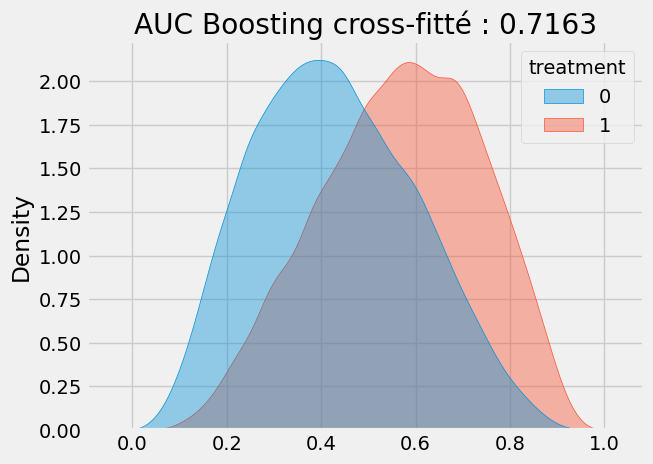

In [34]:
plot_results(ps_values, treatment["treatment"], name="Boosting cross-fitté")

### Étape 3.1 bis : recouvrement, clipping et trimming

**Lecture du graphique.** L'hypothèse de positivité stricte, $0 < e(x) < 1$ avec $e(x)=P(T=1|X=x)$, est respectée : on trouve des traités et des témoins sur presque toute la plage du score de propension. En revanche, le **recouvrement** (*overlap*) est **limité dans les queues** : pour les scores les plus faibles, il n'y a presque que des témoins, et pour les scores les plus élevés presque que des traités. Dans ces zones, l'effet du traitement est estimé à partir d'une poignée d'individus, voire extrapolé.

On parle de **violation pratique** de la positivité. Pour la quantifier, on regarde :
- la répartition traités / témoins par classe de score ;
- les poids d'inverse de probabilité ($1/\hat e$ pour les traités, $1/(1-\hat e)$ pour les témoins) et la **taille d'échantillon effective** (ESS) qu'ils induisent : $ESS = (\sum w_i)^2 / \sum w_i^2$.

In [35]:
# Score de propension cross-fitté, réaligné sur l'index de df_train
ps_train = pd.Series(ps_values, index=treatment.index, name='ps').loc[df_train.index]
print(ps_train.describe(percentiles=[.01, .05, .1, .9, .95, .99]).round(3))

# Répartition traités / témoins par classe de score de propension
classes_ps = [0, .05, .1, .2, .3, .4, .5, .6, .7, .8, .9, .95, 1]
recouvrement = (
    pd.DataFrame({'ps': ps_train, 'treatment': df_train['treatment']})
    .assign(classe_ps=lambda d: pd.cut(d['ps'], classes_ps))
    .groupby('classe_ps', observed=True)['treatment']
    .agg(effectif='size', traites='sum', part_traites='mean')
)
recouvrement['temoins'] = recouvrement['effectif'] - recouvrement['traites']
recouvrement.round(3)

count    35000.000
mean         0.497
std          0.185
min          0.030
1%           0.121
5%           0.196
10%          0.248
50%          0.497
90%          0.745
95%          0.801
99%          0.875
max          0.957
Name: ps, dtype: float64


,effectif,traites,part_traites,temoins
classe_ps,,,,
"(0.0, 0.05]",15,0,0.000,15
"(0.05, 0.1]",163,7,0.043,156
"(0.1, 0.2]",1704,266,0.156,1438
"(0.2, 0.3]",3905,1017,0.260,2888
"(0.3, 0.4]",5538,1910,0.345,3628
"(0.4, 0.5]",6379,2823,0.443,3556
"(0.5, 0.6]",6346,3550,0.559,2796
"(0.6, 0.7]",5493,3558,0.648,1935
"(0.7, 0.8]",3696,2769,0.749,927


In [36]:
T = df_train['treatment']
Y = df_train['outcome']

poids_ipw = np.where(T == 1, 1 / ps_train, 1 / (1 - ps_train))
ess = poids_ipw.sum()**2 / (poids_ipw**2).sum()
print(f"Poids IPW maximal : {poids_ipw.max():.1f}")
print(f"Taille d'échantillon effective (ESS) : {ess:,.0f} sur {len(T):,} observations ({ess/len(T):.0%})")

Poids IPW maximal : 18.2
Taille d'échantillon effective (ESS) : 28,902 sur 35,000 observations (83%)


#### Comment faire du clipping ?

Deux familles de corrections existent. Elles ne répondent pas à la même question :

| | **Clipping** (écrêtage) | **Trimming** (troncature) |
|---|---|---|
| Principe | On remplace $\hat e(x)$ par $\min(\max(\hat e(x), \varepsilon), 1-\varepsilon)$ | On **exclut** les individus dont $\hat e(x) \notin [\alpha, 1-\alpha]$ |
| Effet | Les poids sont bornés à $1/\varepsilon$ : moins de variance, un peu de biais | On travaille sur le **support commun** uniquement |
| Quantité estimée | Toujours l'ATE (approximativement) | L'ATE **sur la sous-population restreinte**, qui n'est plus l'ATE global |
| Seuils usuels | $\varepsilon$ = 0,01 à 0,05 | $\alpha$ = 0,1 (règle de Crump *et al.*, 2009) ou 0,05 |

Une troisième voie consiste à utiliser des **poids de recouvrement** (*overlap weights*, $w = 1-\hat e$ pour les traités, $\hat e$ pour les témoins). Ils estiment l'effet sur la population où traités et témoins se recouvrent le mieux (ATO).

**Règle pratique** : si l'estimation varie peu quand on fait varier $\varepsilon$ ou $\alpha$, le défaut de recouvrement n'est pas un problème pour l'**ATE**. Sinon, il faut le documenter, voire changer de quantité cible.

Ci-dessous, on l'illustre avec l'estimateur le plus exposé : l'IPW pur (pondération par l'inverse du score de propension, sans modèle d'outcome). Le jeu étant simulé, on peut comparer chaque variante à l'ATE réel **de la population qu'elle cible**.

In [37]:
ite = df_train['ite_prob']

def ate_ipw(ps, t, y):
    """Estimateur IPW normalisé (Hájek) de l'ATE."""
    w1, w0 = t / ps, (1 - t) / (1 - ps)
    return (w1 * y).sum() / w1.sum() - (w0 * y).sum() / w0.sum()

lignes = [{'variante': 'IPW sans correction', 'ATE estimé': ate_ipw(ps_train, T, Y),
           'part conservée': 1.0, 'ATE réel (population cible)': ite.mean()}]
for eps in [0.01, 0.05, 0.1]:
    lignes.append({'variante': f'Clipping ε = {eps}', 'ATE estimé': ate_ipw(ps_train.clip(eps, 1 - eps), T, Y),
                   'part conservée': 1.0, 'ATE réel (population cible)': ite.mean()})
for alpha in [0.05, 0.1]:
    m = ps_train.between(alpha, 1 - alpha)
    lignes.append({'variante': f'Trimming [{alpha} ; {1 - alpha:.2f}]', 'ATE estimé': ate_ipw(ps_train[m], T[m], Y[m]),
                   'part conservée': m.mean(), 'ATE réel (population cible)': ite[m].mean()})
pd.DataFrame(lignes).set_index('variante').round(4)

,ATE estimé,part conservée,ATE réel (population cible)
variante,,,
IPW sans correction,0.0479,1.0000,0.0471
Clipping ε = 0.01,0.0479,1.0000,0.0471
Clipping ε = 0.05,0.0479,1.0000,0.0471
Clipping ε = 0.1,0.0481,1.0000,0.0471
Trimming [0.05 ; 0.95],0.0476,0.9995,0.0470
Trimming [0.1 ; 0.90],0.0462,0.9912,0.0463


On retient pour la suite un **support commun** défini par $\hat e(x) \in [0,1 ; 0,9]$ (règle de Crump *et al.*). Il servira à tester la robustesse des estimateurs (étape 3.3) et à signaler les clients pour lesquels l'uplift estimé est peu fiable (politique de ciblage).

In [38]:
ALPHA_TRIM = 0.1
support_commun = ps_train.between(ALPHA_TRIM, 1 - ALPHA_TRIM)
print(f"Part des observations sur le support commun : {support_commun.mean():.1%}")

Part des observations sur le support commun : 99.1%


### Réajustement du modèle DoWhy avec les données

Il faut réajuster le modèle causal DoWhy à partir des données pour bénéficier de l'estimateur.

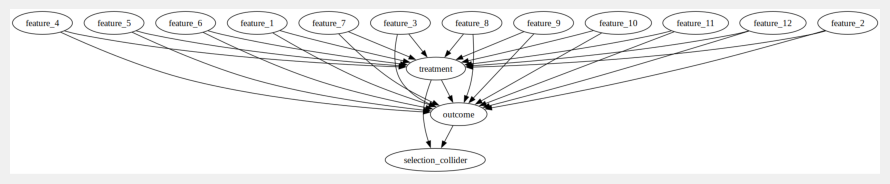

In [39]:
# Définition du modèle causal DoWhy : on indique le traitement et l'outcome
model= CausalModel(data=df_train, # données
        graph=causal_graph, # DAG
        treatment='treatment', # cause d'intérêt, T
        outcome='outcome') # variable d'intérêt, Y
model.view_model(size=(10,30))

In [40]:
identified_estimand = model.identify_effect(proceed_when_unidentifiable=True)
print(identified_estimand)

Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
     d                                                                         ↪
────────────(E[outcome|feature_11,feature_12,feature_5,feature_7,feature_1,fea ↪
d[treatment]                                                                   ↪

↪                                                                      
↪ ture_9,feature_2,feature_8,feature_6,feature_10,feature_3,feature_4])
↪                                                                      
Estimand assumption 1, Unconfoundedness: If U→{treatment} and U→outcome then P(outcome|treatment,feature_11,feature_12,feature_5,feature_7,feature_1,feature_9,feature_2,feature_8,feature_6,feature_10,feature_3,feature_4,U) = P(outcome|treatment,feature_11,feature_12,feature_5,feature_7,feature_1,feature_9,feature_2,feature_8,feature_6,feature_10,feature_3,feature_4)

### Estimand : 2
Estimand name: iv
No such variable(s) found!

### Étape 3.2 : modèle de base

In [41]:
causal_estimate_reg  = model.estimate_effect(identified_estimand,
                                 method_name="backdoor.linear_regression",
                                 test_significance=True,
                                 target_units="ate")

print(causal_estimate_reg )

print(f"ATE réel : {df_train['ite_prob'].mean()}")

*** Causal Estimate ***

## Identified estimand
Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
     d                                                                         ↪
────────────(E[outcome|feature_11,feature_12,feature_5,feature_7,feature_1,fea ↪
d[treatment]                                                                   ↪

↪                                                                      
↪ ture_9,feature_2,feature_8,feature_6,feature_10,feature_3,feature_4])
↪                                                                      
Estimand assumption 1, Unconfoundedness: If U→{treatment} and U→outcome then P(outcome|treatment,feature_11,feature_12,feature_5,feature_7,feature_1,feature_9,feature_2,feature_8,feature_6,feature_10,feature_3,feature_4,U) = P(outcome|treatment,feature_11,feature_12,feature_5,feature_7,feature_1,feature_9,feature_2,feature_8,feature_6,feature_10,feature_3,feature_4)

## Realized e

#### EconML

In [42]:
from catboost import CatBoostClassifier, CatBoostRegressor
from sklearn.ensemble import RandomForestClassifier

ldml_estimate = model.estimate_effect(identified_estimand,
                                    method_name="backdoor.econml.dml.dml.LinearDML",
                                    method_params={
                                        'init_params': {'model_y':RandomForestClassifier(),
                                                        'model_t':RandomForestClassifier(),
                                                        'discrete_treatment':True,
                                                        'discrete_outcome':True
                                                        },
                                        'fit_params': {
                                        }
                                     })
print(ldml_estimate)

print(f"ATE réel : {df_train['ite_prob'].mean()}")

*** Causal Estimate ***

## Identified estimand
Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
     d                                                                         ↪
────────────(E[outcome|feature_11,feature_12,feature_5,feature_7,feature_1,fea ↪
d[treatment]                                                                   ↪

↪                                                                      
↪ ture_9,feature_2,feature_8,feature_6,feature_10,feature_3,feature_4])
↪                                                                      
Estimand assumption 1, Unconfoundedness: If U→{treatment} and U→outcome then P(outcome|treatment,feature_11,feature_12,feature_5,feature_7,feature_1,feature_9,feature_2,feature_8,feature_6,feature_10,feature_3,feature_4,U) = P(outcome|treatment,feature_11,feature_12,feature_5,feature_7,feature_1,feature_9,feature_2,feature_8,feature_6,feature_10,feature_3,feature_4)

## Realized e

In [43]:
ldml_estimate.cate_estimates

array([[[0.04511349]]])

#### DoubleML

Analyse de l'effet de la taille du groupe d'ajustement

In [44]:
from doubleml import DoubleMLData, DoubleMLIRM
from doubleml.utils import PSProcessorConfig

In [45]:
control_set = [f"feature_{k}" for k in range(1,13)]
control_set

['feature_1',
 'feature_2',
 'feature_3',
 'feature_4',
 'feature_5',
 'feature_6',
 'feature_7',
 'feature_8',
 'feature_9',
 'feature_10',
 'feature_11',
 'feature_12']

In [46]:
control_set_collider = control_set + ["selection_collider"]
control_set_collider

['feature_1',
 'feature_2',
 'feature_3',
 'feature_4',
 'feature_5',
 'feature_6',
 'feature_7',
 'feature_8',
 'feature_9',
 'feature_10',
 'feature_11',
 'feature_12',
 'selection_collider']

In [47]:
dml_data = DoubleMLData(df_train,
                        y_col='outcome',
                        d_cols='treatment',
                        x_cols=control_set
                       )
print(dml_data)

================== DoubleMLData Object ==================

------------------ Data summary      ------------------
Outcome variable: outcome
Treatment variable(s): ['treatment']
Covariates: ['feature_1', 'feature_2', 'feature_3', 'feature_4', 'feature_5', 'feature_6', 'feature_7', 'feature_8', 'feature_9', 'feature_10', 'feature_11', 'feature_12']
Instrument variable(s): None
No. Observations: 35000
------------------ DataFrame info    ------------------
<class 'pandas.core.frame.DataFrame'>
Index: 35000 entries, 38094 to 15795
Columns: 19 entries, feature_1 to selection_collider
dtypes: float64(13), int64(5), object(1)
memory usage: 6.3+ MB



In [48]:
dml_irm_tree = DoubleMLIRM(dml_data,
                            ml_g = CatBoostClassifier(verbose=False),
                            ml_m = CatBoostClassifier(verbose=False),
                            ps_processor_config = PSProcessorConfig(clipping_threshold=0.025),
                            n_folds = 3,
                            n_rep = 1,
                            score='ATE'
                          )

print(dml_irm_tree.fit(store_predictions=True))

================== DoubleMLIRM Object ==================

------------------ Data Summary      ------------------
Outcome variable: outcome
Treatment variable(s): ['treatment']
Covariates: ['feature_1', 'feature_2', 'feature_3', 'feature_4', 'feature_5', 'feature_6', 'feature_7', 'feature_8', 'feature_9', 'feature_10', 'feature_11', 'feature_12']
Instrument variable(s): None
No. Observations: 35000

------------------ Score & Algorithm ------------------
Score function: ATE

------------------ Machine Learner   ------------------
Learner ml_g: CatBoostClassifier(verbose=False)
Learner ml_m: CatBoostClassifier(verbose=False)
Out-of-sample Performance:
Classification:
Learner ml_g0 Log Loss: [[0.56622673]]
Learner ml_g1 Log Loss: [[0.49022035]]
Learner ml_m Log Loss: [[0.62394871]]

------------------ Resampling        ------------------
No. folds: 3
No. repeated sample splits: 1

------------------ Fit Summary       ------------------
               coef   std err         t         P>|t

### Impact du collider

In [49]:
dml_data_collider = DoubleMLData(df_train,
                        y_col='outcome',
                        d_cols='treatment',
                        x_cols=control_set_collider
                       )
print(dml_data_collider)

================== DoubleMLData Object ==================

------------------ Data summary      ------------------
Outcome variable: outcome
Treatment variable(s): ['treatment']
Covariates: ['feature_1', 'feature_2', 'feature_3', 'feature_4', 'feature_5', 'feature_6', 'feature_7', 'feature_8', 'feature_9', 'feature_10', 'feature_11', 'feature_12', 'selection_collider']
Instrument variable(s): None
No. Observations: 35000
------------------ DataFrame info    ------------------
<class 'pandas.core.frame.DataFrame'>
Index: 35000 entries, 38094 to 15795
Columns: 19 entries, feature_1 to selection_collider
dtypes: float64(13), int64(5), object(1)
memory usage: 6.3+ MB



In [50]:
dml_irm_tree_collider = DoubleMLIRM(dml_data_collider,
                            ml_g = CatBoostClassifier(verbose=False),
                            ml_m = CatBoostClassifier(verbose=False),
                            ps_processor_config = PSProcessorConfig(clipping_threshold=0.025),
                            n_folds = 3,
                            n_rep = 1,
                            score='ATE'
                          )

print(dml_irm_tree_collider.fit(store_predictions=True))

================== DoubleMLIRM Object ==================

------------------ Data Summary      ------------------
Outcome variable: outcome
Treatment variable(s): ['treatment']
Covariates: ['feature_1', 'feature_2', 'feature_3', 'feature_4', 'feature_5', 'feature_6', 'feature_7', 'feature_8', 'feature_9', 'feature_10', 'feature_11', 'feature_12', 'selection_collider']
Instrument variable(s): None
No. Observations: 35000

------------------ Score & Algorithm ------------------
Score function: ATE

------------------ Machine Learner   ------------------
Learner ml_g: CatBoostClassifier(verbose=False)
Learner ml_m: CatBoostClassifier(verbose=False)
Out-of-sample Performance:
Classification:
Learner ml_g0 Log Loss: [[0.51178241]]
Learner ml_g1 Log Loss: [[0.45343777]]
Learner ml_m Log Loss: [[0.58967267]]

------------------ Resampling        ------------------
No. folds: 3
No. repeated sample splits: 1

------------------ Fit Summary       ------------------
               coef   std err 

Est-ce que ce résultat était prévu ?

### CausalML

CausalML est un package développé par Uber.

In [51]:
from causalml.inference.meta import BaseXClassifier, BaseRClassifier, BaseSClassifier, BaseTClassifier

In [52]:
T_estimate = model.estimate_effect(identified_estimand,
                                    method_name="backdoor.causalml.inference.meta.BaseTClassifier",
                                    method_params={
                                        'init_params': {'learner':CatBoostClassifier(verbose=False),
                                                        },
                                        'fit_params': {
                                        }
                                     })
print(T_estimate)

*** Causal Estimate ***

## Identified estimand
Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
     d                                                                         ↪
────────────(E[outcome|feature_11,feature_12,feature_5,feature_7,feature_1,fea ↪
d[treatment]                                                                   ↪

↪                                                                      
↪ ture_9,feature_2,feature_8,feature_6,feature_10,feature_3,feature_4])
↪                                                                      
Estimand assumption 1, Unconfoundedness: If U→{treatment} and U→outcome then P(outcome|treatment,feature_11,feature_12,feature_5,feature_7,feature_1,feature_9,feature_2,feature_8,feature_6,feature_10,feature_3,feature_4,U) = P(outcome|treatment,feature_11,feature_12,feature_5,feature_7,feature_1,feature_9,feature_2,feature_8,feature_6,feature_10,feature_3,feature_4)

## Realized e

In [53]:
# La liste des variables confondantes est stockée dans l'attribut 'backdoor_variables'
extracted_features = identified_estimand.backdoor_variables

print(extracted_features)

{'backdoor1': ['feature_11', 'feature_12', 'feature_5', 'feature_7', 'feature_1', 'feature_9', 'feature_2', 'feature_8', 'feature_6', 'feature_10', 'feature_3', 'feature_4'], 'backdoor2': ['feature_11', 'feature_12', 'feature_5', 'feature_7', 'feature_1', 'feature_9', 'feature_2', 'feature_8', 'feature_6', 'feature_10', 'feature_3', 'feature_4'], 'backdoor': ['feature_11', 'feature_12', 'feature_5', 'feature_7', 'feature_1', 'feature_9', 'feature_2', 'feature_8', 'feature_6', 'feature_10', 'feature_3', 'feature_4']}


In [54]:
control_set = extracted_features['backdoor']
control_set

['feature_11',
 'feature_12',
 'feature_5',
 'feature_7',
 'feature_1',
 'feature_9',
 'feature_2',
 'feature_8',
 'feature_6',
 'feature_10',
 'feature_3',
 'feature_4']

In [55]:
T_estimate.estimator.estimator.estimate_ate(X=df_train[control_set], treatment=df_train['treatment'], y=df_train['outcome'])

(array([0.04650802]), array([0.03857071]), array([0.05444534]))

In [56]:
print(f"ATE réel : {df_train['ite_prob'].mean()}")

ATE réel : 0.04713635989735324


### Étape 3.3 : robustesse des estimateurs au défaut de recouvrement

Les méthodes utilisées plus haut ne réagissent pas de la même façon au manque de recouvrement :

| Méthode | Utilise $\hat e(x)$ ? | Comportement dans les zones de faible recouvrement | Robustesse |
|---|---|---|---|
| Régression linéaire (DoWhy) | Non | **Extrapole** linéairement l'effet là où un des deux groupes manque | Stable, mais repose entièrement sur la forme du modèle. Pas de clipping possible : seul le trimming s'applique |
| LinearDML (EconML) | Indirectement, via les résidus $T-\hat e(X)$ | Les individus avec $\hat e \approx 0$ ou $1$ ont un résidu proche de 0 : ils pèsent peu (poids $\propto \hat e(1-\hat e)$) | Robuste en variance, mais estime un effet **pondéré par le recouvrement**, égal à l'ATE seulement si l'effet est peu hétérogène |
| DoubleML IRM (AIPW) | Oui, **divise** par $\hat e$ et $1-\hat e$ | Des scores proches de 0 ou 1 font exploser les poids | La plus sensible, d'où le paramètre `clipping_threshold`. Il faut vérifier la sensibilité au seuil |
| T-Learner (CausalML) | Non | Chaque modèle ($\mu_1$ sur les traités, $\mu_0$ sur les témoins) extrapole là où son groupe est rare | L'ATE est peu affecté (peu d'individus concernés), mais les **effets individuels** y sont peu fiables : impact direct sur le ciblage |

Vérifions-le sur nos données.

#### DoubleML : sensibilité au seuil de clipping

DoubleML enregistre le score de propension **après** clipping. On ajuste donc une seule fois les modèles de nuisance avec un écrêtage quasi nul (0,001), puis on réutilise leurs prédictions (`external_predictions`) pour réestimer l'ATE avec différents seuils et sur le support commun, sans réentraîner les modèles.

In [57]:
X_cols = [f"feature_{k}" for k in range(1,13)]

dml_irm_ref = DoubleMLIRM(dml_data,
                          ml_g = CatBoostClassifier(verbose=False),
                          ml_m = CatBoostClassifier(verbose=False),
                          ps_processor_config = PSProcessorConfig(clipping_threshold=1e-3),
                          n_folds = 3,
                          n_rep = 1,
                          score='ATE')
dml_irm_ref.fit(store_predictions=True)
predictions_ref = {'treatment': {nom: dml_irm_ref.predictions[nom][:, :, 0] for nom in ['ml_g0', 'ml_g1', 'ml_m']}}

def dml_depuis_predictions(donnees, predictions, seuil):
    """Réestime l'ATE DoubleML à partir de prédictions de nuisance déjà calculées."""
    dml = DoubleMLIRM(donnees,
                      ml_g = CatBoostClassifier(verbose=False),
                      ml_m = CatBoostClassifier(verbose=False),
                      ps_processor_config = PSProcessorConfig(clipping_threshold=seuil),
                      n_folds = 3, n_rep = 1, score='ATE')
    return dml.fit(external_predictions=predictions)

resultats_dml = []
for seuil in [1e-3, 0.01, 0.025, 0.05, 0.1]:
    est = dml_depuis_predictions(dml_data, predictions_ref, seuil)
    resultats_dml.append({'variante': f'Clipping {seuil}', 'ATE estimé': est.coef[0], 'écart-type': est.se[0],
                          'part conservée': 1.0, 'ATE réel (population cible)': df_train['ite_prob'].mean()})

# Trimming : on ne conserve que le support commun (mêmes prédictions de nuisance, restreintes)
masque = support_commun.values
dml_data_trim = DoubleMLData(df_train[masque], y_col='outcome', d_cols='treatment', x_cols=X_cols)
predictions_trim = {'treatment': {nom: p[masque] for nom, p in predictions_ref['treatment'].items()}}
est = dml_depuis_predictions(dml_data_trim, predictions_trim, 1e-3)
resultats_dml.append({'variante': f'Trimming [{ALPHA_TRIM} ; {1 - ALPHA_TRIM}]', 'ATE estimé': est.coef[0], 'écart-type': est.se[0],
                      'part conservée': masque.mean(), 'ATE réel (population cible)': df_train.loc[masque, 'ite_prob'].mean()})

pd.DataFrame(resultats_dml).set_index('variante').round(4)

,ATE estimé,écart-type,part conservée,ATE réel (population cible)
variante,,,,
Clipping 0.001,0.0463,0.0053,1.0000,0.0471
Clipping 0.01,0.0463,0.0053,1.0000,0.0471
Clipping 0.025,0.0463,0.0053,1.0000,0.0471
Clipping 0.05,0.0465,0.0053,1.0000,0.0471
Clipping 0.1,0.0465,0.0052,1.0000,0.0471
Trimming [0.1 ; 0.9],0.0451,0.0053,0.9912,0.0463


#### LinearDML : quel effet est réellement estimé ?

Sans variable modificatrice d'effet, LinearDML régresse le résidu de l'outcome sur le résidu du traitement. Chaque individu y pèse proportionnellement à $\hat e(1-\hat e)$ : l'estimation converge vers un effet **pondéré par le recouvrement** plutôt que vers l'ATE. Le jeu étant simulé, on peut calculer les deux quantités réelles.

In [58]:
poids_recouvrement = ps_train * (1 - ps_train)
effet_pondere_reel = (poids_recouvrement * df_train['ite_prob']).sum() / poids_recouvrement.sum()

print(f"ATE réel                                   : {df_train['ite_prob'].mean():.4f}")
print(f"Effet réel pondéré par le recouvrement     : {effet_pondere_reel:.4f}")
print(f"Estimation LinearDML                       : {float(np.ravel(ldml_estimate.value)[0]):.4f}")

ATE réel                                   : 0.0471
Effet réel pondéré par le recouvrement     : 0.0443
Estimation LinearDML                       : 0.0451


#### T-Learner : fiabilité des effets individuels selon le score de propension

On compare, sur le jeu de test, l'effet individuel estimé par le T-Learner à l'effet réel, par classe de score de propension. Le score de propension du jeu de test est la moyenne des prédictions des deux modèles cross-fittés.

In [59]:
ps_test = pd.Series((ps_model_boost_1.predict_proba(df_test[X_cols])[:, 1]
                     + ps_model_boost_2.predict_proba(df_test[X_cols])[:, 1]) / 2,
                    index=df_test.index, name='ps')
support_commun_test = ps_test.between(ALPHA_TRIM, 1 - ALPHA_TRIM)

cate_test = T_estimate.estimator.estimator.predict(df_test[control_set].to_numpy())[:, -1]
diag_T = pd.DataFrame({'ps': ps_test, 'cate_estime': cate_test, 'ite_reel': df_test['ite_prob']})
diag_T['erreur_carree'] = (diag_T['cate_estime'] - diag_T['ite_reel'])**2

(diag_T
 .assign(classe_ps=pd.cut(diag_T['ps'], classes_ps))
 .groupby('classe_ps', observed=True)
 .agg(effectif=('ps', 'size'),
      rmse_effet_individuel=('erreur_carree', lambda e: np.sqrt(e.mean())),
      effet_moyen_estime=('cate_estime', 'mean'),
      effet_moyen_reel=('ite_reel', 'mean'))
 .round(3))

,effectif,rmse_effet_individuel,effet_moyen_estime,effet_moyen_reel
classe_ps,,,,
"(0.0, 0.05]",3,0.124,0.367,0.449
"(0.05, 0.1]",59,0.146,0.430,0.386
"(0.1, 0.2]",686,0.125,0.238,0.227
"(0.2, 0.3]",1571,0.107,0.168,0.159
"(0.3, 0.4]",2363,0.091,0.111,0.108
"(0.4, 0.5]",2851,0.089,0.056,0.058
"(0.5, 0.6]",2746,0.088,0.011,0.013
"(0.6, 0.7]",2389,0.082,-0.032,-0.028
"(0.7, 0.8]",1628,0.083,-0.053,-0.048


In [60]:
for nom, m in [('population totale', np.ones(len(diag_T), dtype=bool)), ('support commun', support_commun_test.values)]:
    d = diag_T[m]
    print(f"{nom:<18} | part : {m.mean():6.1%} | ATE estimé : {d['cate_estime'].mean():.4f} | ATE réel : {d['ite_reel'].mean():.4f}"
          f" | RMSE effets individuels : {np.sqrt(d['erreur_carree'].mean()):.3f}")

population totale  | part : 100.0% | ATE estimé : 0.0459 | ATE réel : 0.0460 | RMSE effets individuels : 0.092
support commun     | part :  99.3% | ATE estimé : 0.0449 | ATE réel : 0.0451 | RMSE effets individuels : 0.091


#### À retenir

- **Pour l'ATE**, le défaut de recouvrement de nos données est **modéré** : il ne concerne qu'une faible part des observations (voir le tableau de recouvrement à l'étape 3.1 bis). Les estimations IPW et DoubleML bougent à peine avec le seuil de clipping ou avec le trimming. Le seuil de 0,025 utilisé pour DoubleML est donc un compromis raisonnable.
- **LinearDML** estime en réalité l'effet pondéré par le recouvrement, légèrement différent de l'ATE quand l'effet est hétérogène.
- Le **trimming change la question posée** : on estime l'effet sur le support commun, pas sur toute la population. À présenter comme une analyse de sensibilité, ou comme le résultat principal si la population exclue n'est de toute façon pas ciblable.
- **Pour les effets individuels** (ciblage), les zones de faible recouvrement sont celles où l'erreur du T-Learner est la plus forte, et l'uplift y est surestimé en valeur absolue. Les clients hors support commun doivent être signalés, voire exclus de la politique de ciblage (voir la dernière partie).

## Étape 4 : réfuter

Source : documentation [DoWhy](https://www.pywhy.org/dowhy/v0.9/example_notebooks/dowhy-conditional-treatment-effects.html)

**Pourquoi un estimateur allégé ?** Chaque réfutation modifie les données puis **réestime entièrement** l'effet, et ce pour chaque simulation. Avec le T-Learner, une estimation entraîne 2 CatBoost (traités / témoins) de 1000 arbres, et DoWhy les entraîne 2 fois (une fois pour l'ATE, une fois pour les effets individuels), soit 4 entraînements par simulation.

L'objectif de cette étape est de vérifier la **stabilité** de l'estimation, pas d'obtenir le meilleur modèle : on utilise donc un CatBoost à 100 arbres, environ 10 fois plus rapide.

In [61]:
T_estimate_refut = model.estimate_effect(identified_estimand,
                                    method_name="backdoor.causalml.inference.meta.BaseTClassifier",
                                    method_params={
                                        'init_params': {'learner':CatBoostClassifier(verbose=False, iterations=100),
                                                        },
                                        'fit_params': {
                                        }
                                     })
print(f"ATE estimé (modèle allégé) : {T_estimate_refut.value}")
print(f"ATE estimé (modèle complet) : {T_estimate.value}")

ATE estimé (modèle allégé) : [0.0461696]
ATE estimé (modèle complet) : [0.04650802]


Ajout d'une cause commune aléatoire

In [62]:
res_random=model.refute_estimate(identified_estimand, T_estimate_refut, method_name="random_common_cause",
        num_simulations=10 # au moins 100 serait préférable, 10 pour la rapidité
        )
print(res_random)

             Note: The underlying distribution may not be Normal. We assume that it approaches normal with the increase in sample size.


Refute: Add a random common cause
Estimated effect:[0.0461696]
New effect:0.04676380487901253
p value:[0.02409765]



Ajout d'une cause commune non observée

In [63]:
# Traitement et outcome sont binaires : on utilise "binary_flip" (un effet "linear" rendrait
# treatment/outcome continus, ce qui fait échouer le T-Learner de CausalML)
res_unobserved=model.refute_estimate(identified_estimand, T_estimate_refut, method_name="add_unobserved_common_cause",
                                     confounders_effect_on_treatment="binary_flip", confounders_effect_on_outcome="binary_flip",
                                    effect_strength_on_treatment=0.01, effect_strength_on_outcome=0.02)
print(res_unobserved)

Refute: Add an Unobserved Common Cause
Estimated effect:[0.0461696]
New effect:[0.04342353]



Remplacement du traitement par une variable aléatoire (placebo)

In [64]:
res_placebo=model.refute_estimate(identified_estimand, T_estimate_refut,
        method_name="placebo_treatment_refuter", placebo_type="permute",
        num_simulations=10 # au moins 100 serait préférable, 10 pour la rapidité
        )
print(res_placebo)

             Note: The underlying distribution may not be Normal. We assume that it approaches normal with the increase in sample size.


Refute: Use a Placebo Treatment
Estimated effect:[0.0461696]
New effect:-0.0019438800587658314
p value:0.3664791315209802



Suppression d'un sous-ensemble aléatoire des données

In [65]:
res_subset=model.refute_estimate(identified_estimand, T_estimate_refut,
        method_name="data_subset_refuter", subset_fraction=0.8,
        num_simulations=10)
print(res_subset)

             Note: The underlying distribution may not be Normal. We assume that it approaches normal with the increase in sample size.


Refute: Use a subset of data
Estimated effect:[0.0461696]
New effect:0.04733778111477961
p value:[0.26607857]



# Application : définition d'une politique de ciblage

In [66]:
# La liste des variables confondantes est stockée dans l'attribut 'backdoor_variables'
extracted_features = identified_estimand.backdoor_variables

print(extracted_features)

{'backdoor1': ['feature_11', 'feature_12', 'feature_5', 'feature_7', 'feature_1', 'feature_9', 'feature_2', 'feature_8', 'feature_6', 'feature_10', 'feature_3', 'feature_4'], 'backdoor2': ['feature_11', 'feature_12', 'feature_5', 'feature_7', 'feature_1', 'feature_9', 'feature_2', 'feature_8', 'feature_6', 'feature_10', 'feature_3', 'feature_4'], 'backdoor': ['feature_11', 'feature_12', 'feature_5', 'feature_7', 'feature_1', 'feature_9', 'feature_2', 'feature_8', 'feature_6', 'feature_10', 'feature_3', 'feature_4']}


In [67]:
backdoor_set = extracted_features['backdoor']
backdoor_set
X_test_np = df_test[backdoor_set].to_numpy()
predictions_array = T_estimate.estimator.estimator.predict(X_test_np)
predicted_cate_T = predictions_array[:, -1]
predicted_cate_T

array([-0.64906324, -0.11074241,  0.17417509, ...,  0.3856462 ,
       -0.27604403, -0.17855757])

In [68]:
# --- Évaluation du modèle d'uplift ---

eval_df = pd.DataFrame({
    'y_true': df_test['outcome'],
    'treatment': df_test['treatment'],
    'ite_true': df_test['ite_prob'],
    'réel': df_test['ite_prob'],
    'T_cate': predicted_cate_T
})

In [69]:
from causalml.metrics import auuc_score

In [70]:
auuc = auuc_score(eval_df, outcome_col='y_true', treatment_col='treatment',
                  score_col='T_cate', ite_col='ite_true')
print(f"\nScore AUUC final : {auuc['T_cate']:.4f}")


Score AUUC final : 1.3816


In [71]:
from causalml.metrics import plot_gain, plot_qini

In [72]:
eval_df

,y_true,treatment,ite_true,réel,T_cate
33553,1,0,-0.568206,-0.568206,-0.649063
9427,1,1,-0.059419,-0.059419,-0.110742
199,0,1,0.232746,0.232746,0.174175
12447,1,0,0.279019,0.279019,0.265304
39489,0,0,0.130570,0.130570,0.152361
...,...,...,...,...,...
15168,1,0,0.474409,0.474409,0.390862
49241,1,0,-0.344522,-0.344522,-0.340042
39317,0,1,0.250114,0.250114,0.385646
42191,1,0,-0.235672,-0.235672,-0.276044


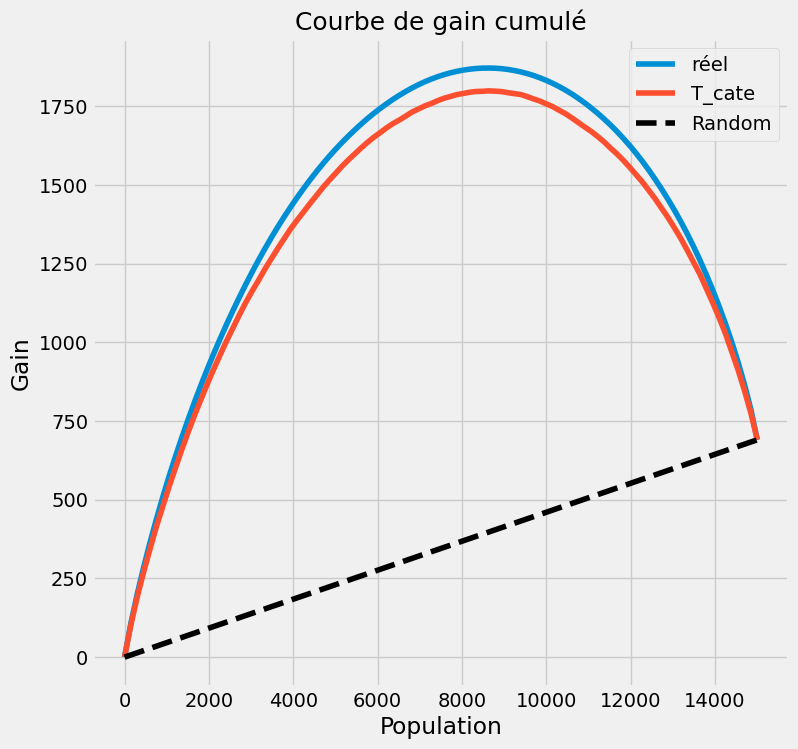

In [73]:
# Courbe de gain cumulé
plot_gain(eval_df,
          outcome_col='y_true',
          treatment_col='treatment',
          treatment_effect_col='ite_true')
plt.title("Courbe de gain cumulé", fontsize=18)
plt.show()

In [74]:
T_estimate.estimator.estimator.estimate_ate(X=df_test[control_set], treatment=df_test['treatment'], y=df_test['outcome'])

(array([0.03483253]), array([0.02346219]), array([0.04620287]))

In [75]:
eval_df.groupby(['treatment']).sum()

,y_true,ite_true,réel,T_cate
treatment,,,,
0,5083,556.029724,556.029724,558.250370
1,5793,134.284208,134.284208,130.743204


In [76]:
3559 - 2244

1315

In [77]:
eval_df.sum()

,0
y_true,10876.000000
treatment,7596.000000
ite_true,690.313933
réel,690.313933
T_cate,688.993575


In [78]:
# Tri des résultats par uplift estimé décroissant
uplift_results = eval_df
uplift_results['user_id'] = eval_df.index
uplift_results_sorted_T = uplift_results.sort_values(by='T_cate', ascending=False).reset_index(drop=True)

# Affichage de la liste des clients
print("Liste des clients triée par uplift (T-Learner) :")
display(uplift_results_sorted_T[['user_id', 'T_cate']].head(10))

Liste des clients triée par uplift (T-Learner) :


,user_id,T_cate
0,49262,0.929423
1,36003,0.918268
2,10890,0.917526
3,25151,0.899311
4,18795,0.895868
5,37154,0.893767
6,23974,0.889532
7,2868,0.871668
8,37087,0.862048
9,11107,0.861126


In [79]:
# Calcul du rang et du décile
uplift_results_sorted_T['rank'] = uplift_results_sorted_T['T_cate'].rank(method='first', ascending=False)
uplift_results_sorted_T['decile'] = pd.qcut(uplift_results_sorted_T['rank'], 10, labels=False)

decile_labels = [
    "top 10 %", "top 10-20 %", "top 20-30 %", "top 30-40 %", "top 40-50 %",
    "top 50-60 %", "top 60-70 %", "top 70-80 %", "top 80-90 %", "derniers 10 %"
]

column_order = ['user_id', 'T_cate', 'rank', 'decile', 'decile_label']
uplift_results_sorted_T['decile_label'] = uplift_results_sorted_T['decile'].map(lambda x: decile_labels[x])
display(uplift_results_sorted_T[column_order].head(10))

,user_id,T_cate,rank,decile,decile_label
0,49262,0.929423,1.0,0,top 10 %
1,36003,0.918268,2.0,0,top 10 %
2,10890,0.917526,3.0,0,top 10 %
3,25151,0.899311,4.0,0,top 10 %
4,18795,0.895868,5.0,0,top 10 %
5,37154,0.893767,6.0,0,top 10 %
6,23974,0.889532,7.0,0,top 10 %
7,2868,0.871668,8.0,0,top 10 %
8,37087,0.862048,9.0,0,top 10 %
9,11107,0.861126,10.0,0,top 10 %


In [80]:
uplift_results_sorted_T[uplift_results_sorted_T['T_cate']<=0]

,y_true,treatment,ite_true,réel,T_cate,user_id,rank,decile,decile_label
8533,1,1,0.065168,0.065168,-0.000099,3180,8534.0,5,top 50-60 %
8534,1,0,0.121702,0.121702,-0.000106,18331,8535.0,5,top 50-60 %
8535,0,0,-0.081765,-0.081765,-0.000109,6399,8536.0,5,top 50-60 %
8536,1,0,0.098905,0.098905,-0.000117,5134,8537.0,5,top 50-60 %
8537,1,1,0.126653,0.126653,-0.000184,35279,8538.0,5,top 50-60 %
...,...,...,...,...,...,...,...,...,...
14995,0,1,-0.619893,-0.619893,-0.814368,7969,14996.0,9,derniers 10 %
14996,0,1,-0.596158,-0.596158,-0.827586,8406,14997.0,9,derniers 10 %
14997,0,1,-0.809210,-0.809210,-0.844358,12486,14998.0,9,derniers 10 %
14998,1,0,-0.855465,-0.855465,-0.875354,12955,14999.0,9,derniers 10 %


#### Clients hors support commun

Pour les clients dont le score de propension sort de $[0,1 ; 0,9]$, l'uplift estimé repose sur une extrapolation (étape 3.3). On les signale dans la liste de ciblage.

In [81]:
uplift_results_sorted_T['ps'] = ps_test.loc[uplift_results_sorted_T['user_id']].values
uplift_results_sorted_T['support_commun'] = uplift_results_sorted_T['ps'].between(ALPHA_TRIM, 1 - ALPHA_TRIM)

(uplift_results_sorted_T
 .groupby('decile_label', sort=False)
 .agg(effectif=('user_id', 'size'),
      part_hors_support=('support_commun', lambda s: 1 - s.mean()),
      uplift_moyen_estime=('T_cate', 'mean'),
      uplift_moyen_reel=('ite_true', 'mean'))
 .round(3))

,effectif,part_hors_support,uplift_moyen_estime,uplift_moyen_reel
decile_label,,,,
top 10 %,1500,0.024,0.532,0.475
top 10-20 %,1500,0.005,0.321,0.296
top 20-30 %,1500,0.005,0.215,0.201
top 30-40 %,1500,0.002,0.138,0.135
top 40-50 %,1500,0.005,0.073,0.074
top 50-60 %,1500,0.005,0.011,0.016
top 60-70 %,1500,0.007,-0.051,-0.049
top 70-80 %,1500,0.003,-0.123,-0.113
top 80-90 %,1500,0.005,-0.223,-0.200


In [82]:
fig = px.scatter(eval_df, x="T_cate", y="ite_true", marginal_x="histogram", marginal_y="histogram")
fig.show()